In [43]:
# Imports

from keras.datasets import cifar10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import set_random_seed, to_categorical
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

set_random_seed(1024) # Set a global seed to grant reproducibility

# Carregamento dos datasets

Aqui a gente vai explicar que vamos utilizar o mnist e o CIFAR 10, dizer sobre o que cada um deles se trata

In [44]:
# Loading mnist dataset

# Loading CIFAR-10 dataset

(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()

cifar_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print('Cifar-10 train images shape:      ', cifar_x_train.shape)
print('Cifar-10 train labels shape:      ', cifar_y_train.shape)

print('\nCifar-10 test images shape:       ', cifar_x_test.shape)
print('Cifar-10 test labels shape:       ', cifar_y_test.shape)

Cifar-10 train images shape:       (50000, 32, 32, 3)
Cifar-10 train labels shape:       (50000, 1)

Cifar-10 test images shape:        (10000, 32, 32, 3)
Cifar-10 test labels shape:        (10000, 1)


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


# Visualização dos dados

Segue abaixo uma visualização das primeiras imagens de ambos os datasets:

In [45]:
def show_images_samples(dataset_name,x_train, y_train, x_test, y_test, class_names, n_samples=8, cmap=None):
    """
    Show some samples of the dataset.
    """
    figure, axes = plt.subplots(2, n_samples, figsize=(15, 6))

    figure.suptitle(f'{dataset_name} - Image Samples', fontsize=16)
    figure.text(0.5, 0.88, 'Training', fontsize=16, ha='center')    
    figure.text(0.5, 0.47, 'Test', fontsize=16, ha='center')    

    for i in range(n_samples):
        # Show training samples
        axes[0, i].imshow(x_train[i], cmap=cmap)
        axes[0, i].set_title(f'{class_names[y_train[i][0]]}')
        axes[0, i].axis('off')
        
        # Show test samples
        axes[1, i].imshow(x_test[i], cmap=cmap)
        axes[1, i].set_title(f'{class_names[y_test[i][0]]}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

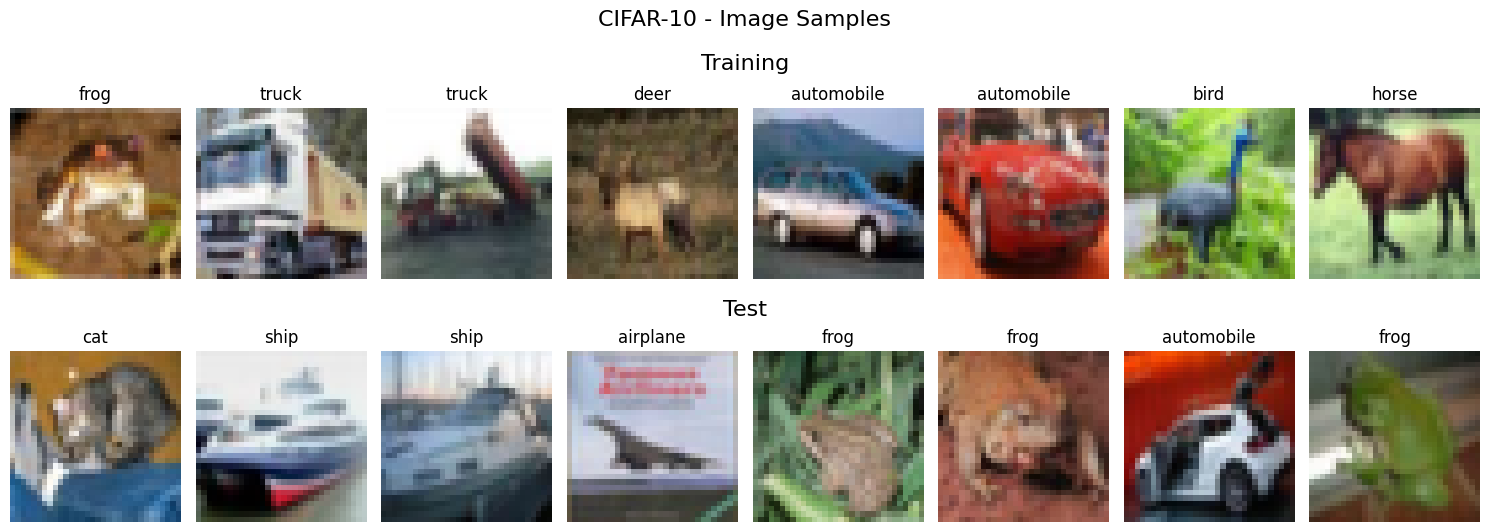

In [46]:
show_images_samples(
    "CIFAR-10",
    cifar_x_train, 
    cifar_y_train, 
    cifar_x_test, 
    cifar_y_test, 
    cifar_class_names
)

# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento sobre o sataset do *CIFAR-10*:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [47]:
def convert_to_grayscale(x_train, x_test):
    """
    Convert the images from RGB to grayscale using the standard formula: Y = 0.299 R + 0.587 G + 0.114 B
    """
    x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
    x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])
    
    return x_train_gray, x_test_gray

In [48]:
# Convert the images from RGB to grayscale

# standard formula: Y = 0.299 R + 0.587 G + 0.114 B
cifar_x_train_gray, cifar_x_test_gray = convert_to_grayscale(cifar_x_train, cifar_x_test)

print('CIFAR-10 train images shape (Gray scale):      ', cifar_x_train_gray.shape)
print('CIFAR-10 test images shape (Gray scale):       ', cifar_x_test_gray.shape)

CIFAR-10 train images shape (Gray scale):       (50000, 32, 32)
CIFAR-10 test images shape (Gray scale):        (10000, 32, 32)


In [49]:
def flatten_and_normalize_images(x_train, x_test):
    """
    Flatten the images and normalize to [0, 1] (improves stability and accuracy).
    """
    x_train_flat = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.0
    x_test_flat = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.0

    return pd.DataFrame(x_train_flat), pd.DataFrame(x_test_flat)

def convert_label_to_one_hot(y_train, y_test, num_classes=10):
    """
    Convert the labels to one-hot encoding.
    """
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)

    return pd.DataFrame(y_train_one_hot), pd.DataFrame(y_test_one_hot)

In [50]:
# Flatten the images and normalize to [0, 1] (improves stability and accuracy)

cifar_x_train_gray_flat_df, cifar_x_test_gray_flat_df = flatten_and_normalize_images(cifar_x_train_gray, cifar_x_test_gray)

print('CIFAR-10 train images shape (Gray scale & Flatten):      ', cifar_x_train_gray_flat_df.shape)
print('CIFAR-10 test images shape (Gray scale & Flatten):       ', cifar_x_test_gray_flat_df.shape)

# Convert the labels to one-hot encoding

cifar_y_train_cat_df, cifar_y_test_cat_df = convert_label_to_one_hot(cifar_y_train, cifar_y_test)

print('CIFAR-10 train labels shape (One-hot):      ', cifar_y_train_cat_df.shape)

CIFAR-10 train images shape (Gray scale & Flatten):       (50000, 1024)
CIFAR-10 test images shape (Gray scale & Flatten):        (10000, 1024)
CIFAR-10 train labels shape (One-hot):       (50000, 10)


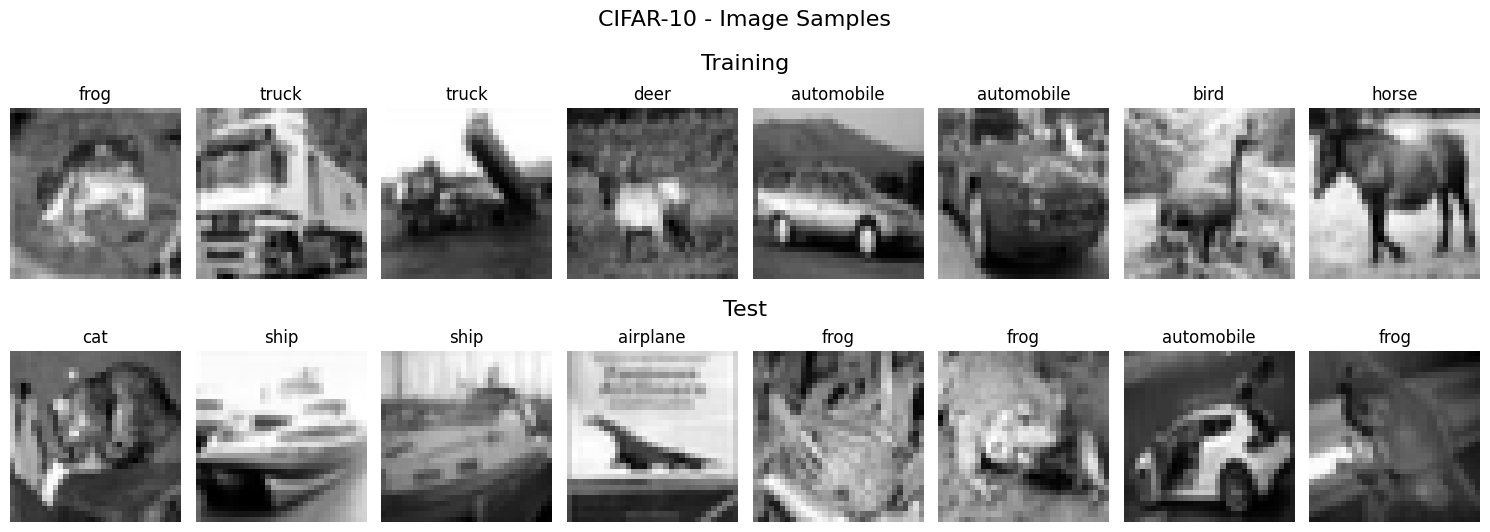

In [51]:
show_images_samples(
    "CIFAR-10",
    cifar_x_train_gray_flat_df.to_numpy().reshape(-1, 32, 32),
    cifar_y_train, 
    cifar_x_test_gray_flat_df.to_numpy().reshape(-1, 32, 32), 
    cifar_y_test, 
    cifar_class_names, 
    cmap='gray'
)

# Estrutura da rede

In [52]:
# Hiper-parâmetros

input_shape = 1024                  # 32 x 32 x 1
epochs = 50                         # https://keras.io/examples/vision/mlp_image_classification/
batch_size = 128                    # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
dropout_rate = 0.2                  # https://keras.io/examples/vision/mlp_image_classification/
learning_rate = 0.001               # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
early_stopping_patience = 5       # https://keras.io/api/callbacks/early_stopping/

#Outras Fontes
#https://pvss.github.io/MLP+of+CIFAR-10
#https://www.kaggle.com/code/yorkyong/exploring-cifar-10-w-mlp-cnn-resnet

In [53]:
# MLP model construction

# Structure based on the article
# "UTILIZAÇÃO DE REDES NEURAIS ARTIFICIAIS PARA A CLASSIFICAÇÃO DECORROSÃO POR PITE OBSERVADAS EM IMAGENS OBTIDAS COM O ENSAIO NÃO INVASIVO DE QUEDA DE POTENCIAL"
# by GABRIEL PEREIRA HOLANDA BARRETO (https://repositorio.ufc.br/bitstream/riufc/83115/1/2025_tcc_gphbarreto.pdf)

def create_mlp_model(dropout_rate=None):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def train_model(model, x_train, y_train, epochs=epochs, batch_size=batch_size, early_stopping=False, patience=None):
    callbacks = []

    if early_stopping:
        callbacks.append(
            EarlyStopping(
                monitor='val_loss', 
                patience=patience, 
                restore_best_weights=True
            )
        )

    history = model.fit(
        x_train, y_train,
        validation_split=0.1,  # Use 10% of the training data for validation
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    return history

def show_experiment_results(history, dataset_name=""):
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ---------------------------
    # Accuracy
    # ---------------------------
    axes[0].plot(
        history.history['accuracy'],
        '--',
        label='Train'
    )

    axes[0].plot(
        history.history['val_accuracy'],
        '-',
        label='Validation'
    )

    axes[0].set_title(f'{dataset_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # ---------------------------
    # Loss
    # ---------------------------
    axes[1].plot(
        history.history['loss'],
        '--',
        label='Train'
    )

    axes[1].plot(
        history.history['val_loss'],
        '-',
        label='Validation'
    )

    axes[1].set_title(f'{dataset_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # ---------------------------
    # Final metrics
    # ---------------------------
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    generalization_gap = val_loss - train_loss

    print(f'  Train loss      : {train_loss:.4f}')
    print(f'  Validation loss : {val_loss:.4f}')
    print(f'  Train accuracy  : {train_acc:.4f}')
    print(f'  Validation acc  : {val_acc:.4f}')
    print(f'  Generalization gap (val - train loss): {generalization_gap:.4f}')
    

def run_experiment(dataset_name, x_train, y_train, x_test, y_test, dropout_rate=0, early_stopping=False, patience=None):
    model = create_mlp_model(dropout_rate=dropout_rate)
    history = train_model(model, x_train, y_train, epochs=epochs, batch_size=batch_size, early_stopping=early_stopping, patience=patience)

    show_experiment_results(history, dataset_name)

    train_acc = history.history['accuracy'][-1] 

    loss, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    return train_acc, acc, loss

# Experimento 1 - Sem dropout e sem early stop

Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2393 - loss: 2.0812 - val_accuracy: 0.2802 - val_loss: 2.0186
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2964 - loss: 1.9553 - val_accuracy: 0.3120 - val_loss: 1.9472
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3200 - loss: 1.8969 - val_accuracy: 0.3278 - val_loss: 1.9053
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3356 - loss: 1.8609 - val_accuracy: 0.3404 - val_loss: 1.8691
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3466 - loss: 1.8346 - val_accuracy: 0.3430 - val_loss: 1.8497
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3558 - loss: 1.8135 - val_accuracy: 0.3548 - val_loss: 1.8290
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3609 - loss: 1.7980 - val_accuracy: 0.3602 - val_loss: 1.8178
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3670 - loss: 1.7851 - val_accuracy: 0.3548 - val_

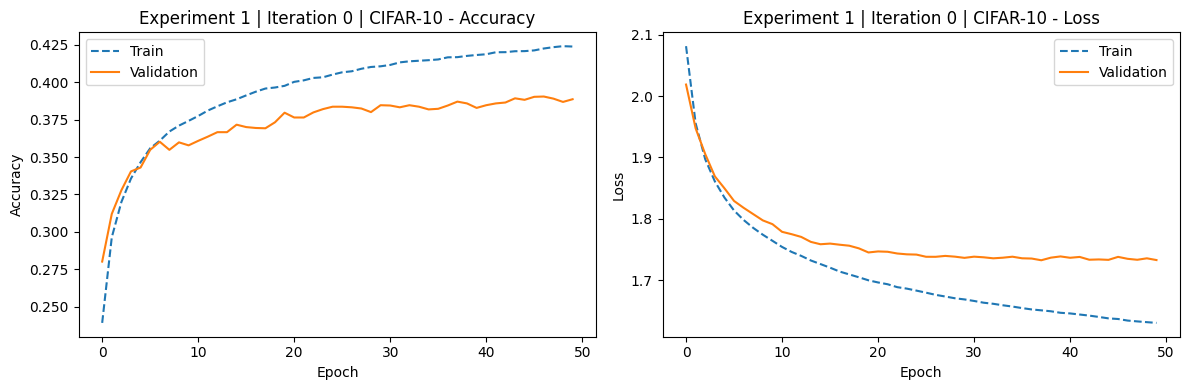

  Train loss      : 1.6304
  Validation loss : 1.7328
  Train accuracy  : 0.4238
  Validation acc  : 0.3886
  Generalization gap (val - train loss): 0.1023
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2155 - loss: 2.1197 - val_accuracy: 0.2514 - val_loss: 2.0683
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2686 - loss: 2.0123 - val_accuracy: 0.2872 - val_loss: 2.0015
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2939 - loss: 1.9561 - val_accuracy: 0.2962 - val_loss: 1.9594
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3086 - loss: 1.9220 - val_accuracy: 0.3108 - val_loss: 1.9245
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3164 - loss: 1.9024 - val_accuracy: 0.3130 - val_loss: 1.9150
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3218 - loss: 1.8886 - val_accuracy: 0.3138 - val_loss: 1.9006
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3264 - loss: 1.8782 - val_accuracy: 0.3176 - val_loss: 1.8937
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3313 - loss: 1.8705 - val_accuracy: 0.3216 - val_

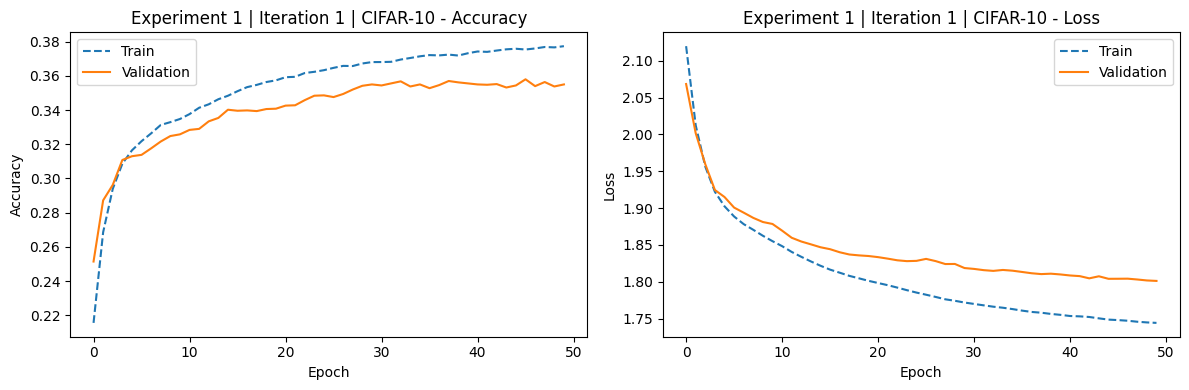

  Train loss      : 1.7442
  Validation loss : 1.8011
  Train accuracy  : 0.3774
  Validation acc  : 0.3550
  Generalization gap (val - train loss): 0.0570
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2328 - loss: 2.0972 - val_accuracy: 0.2662 - val_loss: 2.0332
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2923 - loss: 1.9741 - val_accuracy: 0.2888 - val_loss: 1.9755
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3166 - loss: 1.9160 - val_accuracy: 0.3090 - val_loss: 1.9404
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3307 - loss: 1.8767 - val_accuracy: 0.3224 - val_loss: 1.9090
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3408 - loss: 1.8495 - val_accuracy: 0.3374 - val_loss: 1.8749
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3472 - loss: 1.8302 - val_accuracy: 0.3438 - val_loss: 1.8616
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3537 - loss: 1.8135 - val_accuracy: 0.3484 - val_loss: 1.8430
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3597 - loss: 1.7998 - val_accuracy: 0.3518 - val_

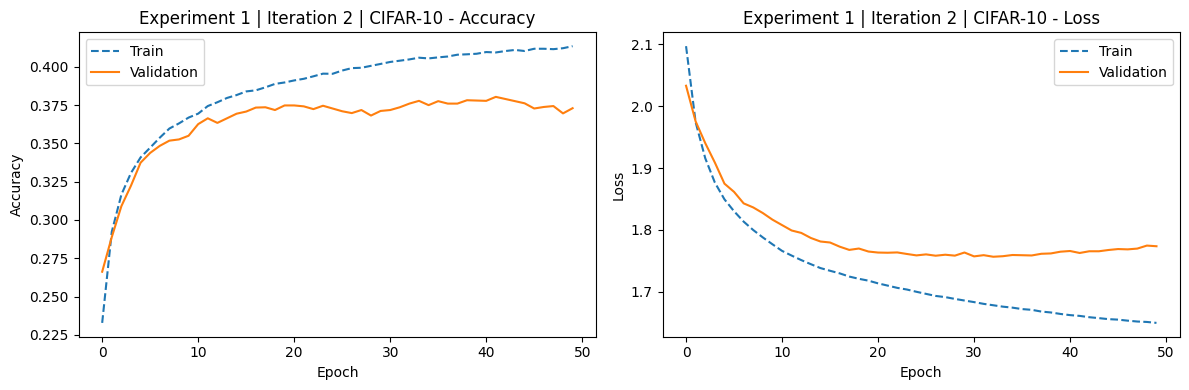

  Train loss      : 1.6497
  Validation loss : 1.7736
  Train accuracy  : 0.4135
  Validation acc  : 0.3730
  Generalization gap (val - train loss): 0.1240


In [54]:
# Training and evaluating the model

for i in range(3):
    run_experiment(
        f"Experiment 1 | Iteration {i} | CIFAR-10",
        cifar_x_train_gray_flat_df, 
        cifar_y_train_cat_df, 
        cifar_x_test_gray_flat_df, 
        cifar_y_test_cat_df
    )

# Experimento 2 - Sem dropout e com early stop

Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2227 - loss: 2.1120 - val_accuracy: 0.2638 - val_loss: 2.0518
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2819 - loss: 2.0006 - val_accuracy: 0.2964 - val_loss: 1.9895
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3008 - loss: 1.9558 - val_accuracy: 0.3104 - val_loss: 1.9576
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3132 - loss: 1.9245 - val_accuracy: 0.3256 - val_loss: 1.9249
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3232 - loss: 1.8986 - val_accuracy: 0.3288 - val_loss: 1.9045
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3300 - loss: 1.8793 - val_accuracy: 0.3310 - val_loss: 1.8938
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3355 - loss: 1.8639 - val_accuracy: 0.3386 - val_loss: 1.8779
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3383 - loss: 1.8523 - val_accuracy: 0.3442 - val_

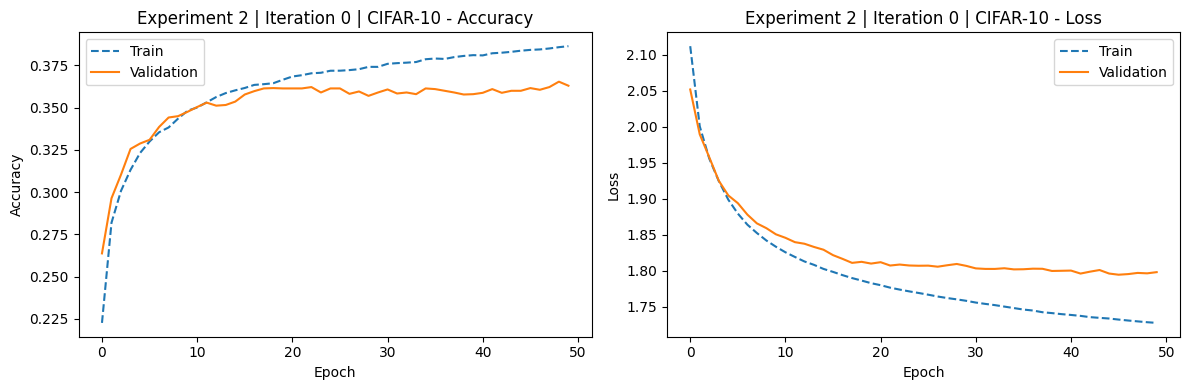

  Train loss      : 1.7274
  Validation loss : 1.7979
  Train accuracy  : 0.3864
  Validation acc  : 0.3630
  Generalization gap (val - train loss): 0.0705
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2324 - loss: 2.0897 - val_accuracy: 0.2672 - val_loss: 2.0309
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2938 - loss: 1.9614 - val_accuracy: 0.2938 - val_loss: 1.9683
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3201 - loss: 1.9042 - val_accuracy: 0.3224 - val_loss: 1.9147
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3328 - loss: 1.8718 - val_accuracy: 0.3366 - val_loss: 1.8807
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3431 - loss: 1.8478 - val_accuracy: 0.3432 - val_loss: 1.8560
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3518 - loss: 1.8279 - val_accuracy: 0.3494 - val_loss: 1.8374
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3580 - loss: 1.8108 - val_accuracy: 0.3564 - val_loss: 1.8273
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3638 - loss: 1.7975 - val_accuracy: 0.3568 - val_

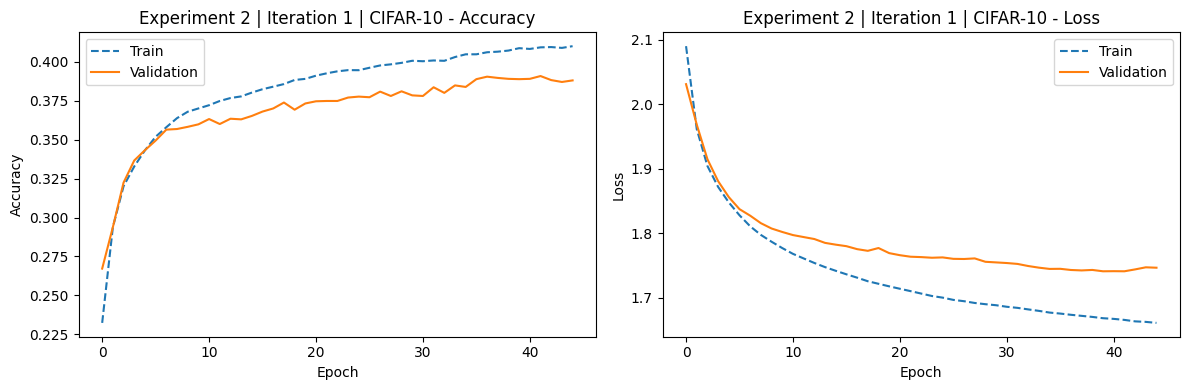

  Train loss      : 1.6613
  Validation loss : 1.7467
  Train accuracy  : 0.4100
  Validation acc  : 0.3880
  Generalization gap (val - train loss): 0.0854
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2401 - loss: 2.0890 - val_accuracy: 0.2700 - val_loss: 2.0449
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2961 - loss: 1.9633 - val_accuracy: 0.3030 - val_loss: 1.9512
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3198 - loss: 1.9031 - val_accuracy: 0.3248 - val_loss: 1.9038
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3345 - loss: 1.8699 - val_accuracy: 0.3440 - val_loss: 1.8732
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3447 - loss: 1.8480 - val_accuracy: 0.3550 - val_loss: 1.8475
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3536 - loss: 1.8286 - val_accuracy: 0.3538 - val_loss: 1.8355
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3583 - loss: 1.8114 - val_accuracy: 0.3586 - val_loss: 1.8263
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3640 - loss: 1.7967 - val_accuracy: 0.3612 - val_

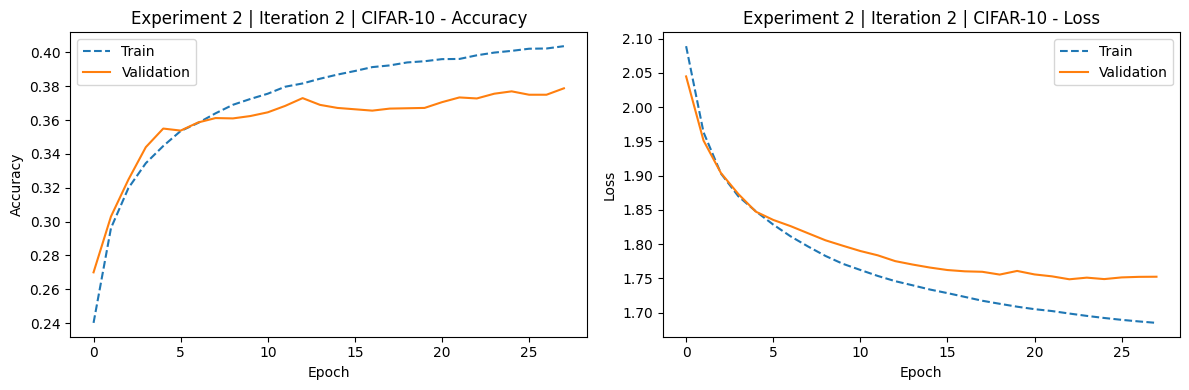

  Train loss      : 1.6852
  Validation loss : 1.7525
  Train accuracy  : 0.4037
  Validation acc  : 0.3788
  Generalization gap (val - train loss): 0.0674


In [55]:
# Training and evaluating the model

for i in range(3):
    run_experiment(
        f"Experiment 2 | Iteration {i} | CIFAR-10",
        cifar_x_train_gray_flat_df, 
        cifar_y_train_cat_df, 
        cifar_x_test_gray_flat_df, 
        cifar_y_test_cat_df,
        early_stopping=True,
        patience=early_stopping_patience
    )

# Experimento 3 - Com dropout e sem early stop

Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1888 - loss: 2.1651 - val_accuracy: 0.2600 - val_loss: 2.0686
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2336 - loss: 2.0869 - val_accuracy: 0.2882 - val_loss: 2.0255
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2465 - loss: 2.0635 - val_accuracy: 0.2840 - val_loss: 2.0184
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2509 - loss: 2.0456 - val_accuracy: 0.2906 - val_loss: 1.9991
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2571 - loss: 2.0372 - val_accuracy: 0.2966 - val_loss: 2.0034
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2638 - loss: 2.0294 - val_accuracy: 0.2972 - val_loss: 1.9900
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2683 - loss: 2.0183 - val_accuracy: 0.2890 - val_loss: 1.9988
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2702 - loss: 2.0066 - val_accuracy: 0.3004 - val_

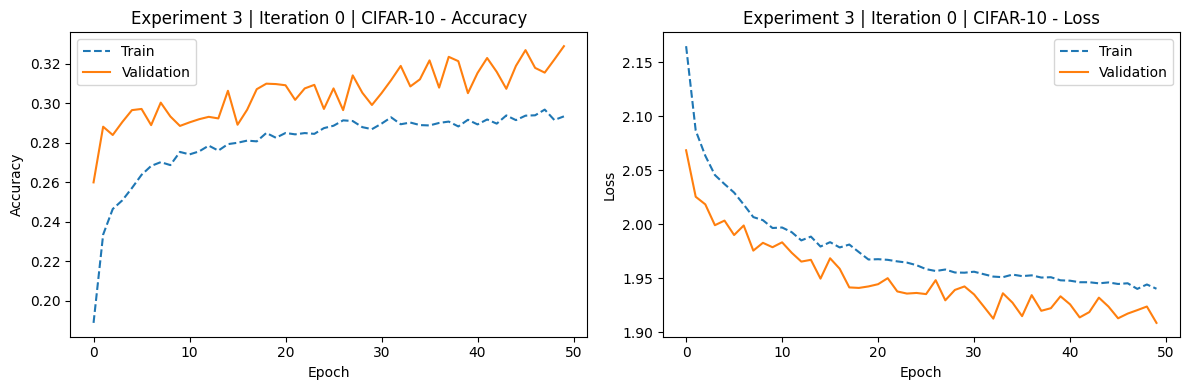

  Train loss      : 1.9402
  Validation loss : 1.9085
  Train accuracy  : 0.2934
  Validation acc  : 0.3290
  Generalization gap (val - train loss): -0.0317
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1840 - loss: 2.1686 - val_accuracy: 0.2524 - val_loss: 2.0576
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2363 - loss: 2.0806 - val_accuracy: 0.2784 - val_loss: 2.0199
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2518 - loss: 2.0442 - val_accuracy: 0.2996 - val_loss: 1.9847
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2577 - loss: 2.0274 - val_accuracy: 0.3088 - val_loss: 1.9537
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2626 - loss: 2.0166 - val_accuracy: 0.3098 - val_loss: 1.9592
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2666 - loss: 2.0013 - val_accuracy: 0.3098 - val_loss: 1.9587
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2716 - loss: 1.9970 - val_accuracy: 0.3082 - val_loss: 1.9494
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2742 - loss: 1.9870 - val_accuracy: 0.3036 - val_

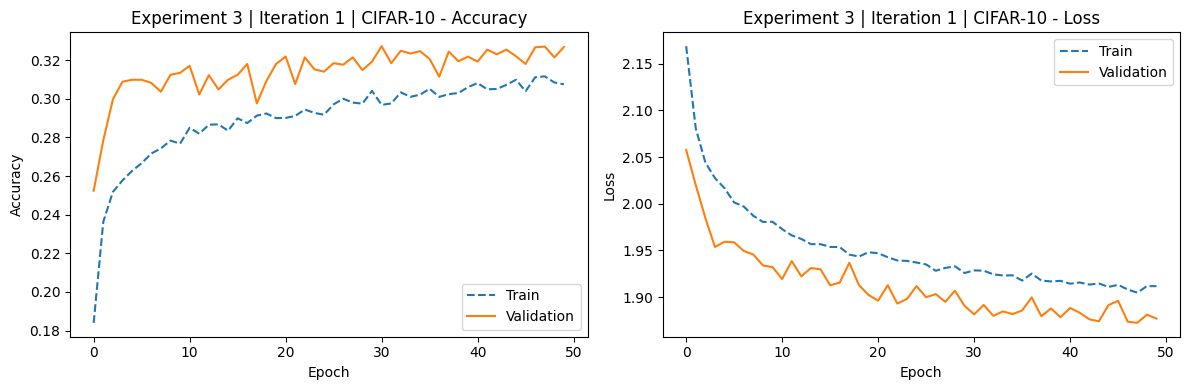

  Train loss      : 1.9118
  Validation loss : 1.8771
  Train accuracy  : 0.3075
  Validation acc  : 0.3268
  Generalization gap (val - train loss): -0.0347
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1459 - loss: 2.2283 - val_accuracy: 0.1978 - val_loss: 2.1518
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1800 - loss: 2.1658 - val_accuracy: 0.2162 - val_loss: 2.1174
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1940 - loss: 2.1399 - val_accuracy: 0.2218 - val_loss: 2.0992
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2000 - loss: 2.1300 - val_accuracy: 0.2206 - val_loss: 2.1017
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2048 - loss: 2.1201 - val_accuracy: 0.2392 - val_loss: 2.0641
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2220 - loss: 2.0901 - val_accuracy: 0.2386 - val_loss: 2.0541
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2234 - loss: 2.0817 - val_accuracy: 0.2358 - val_loss: 2.0631
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2262 - loss: 2.0765 - val_accuracy: 0.2330 - val_

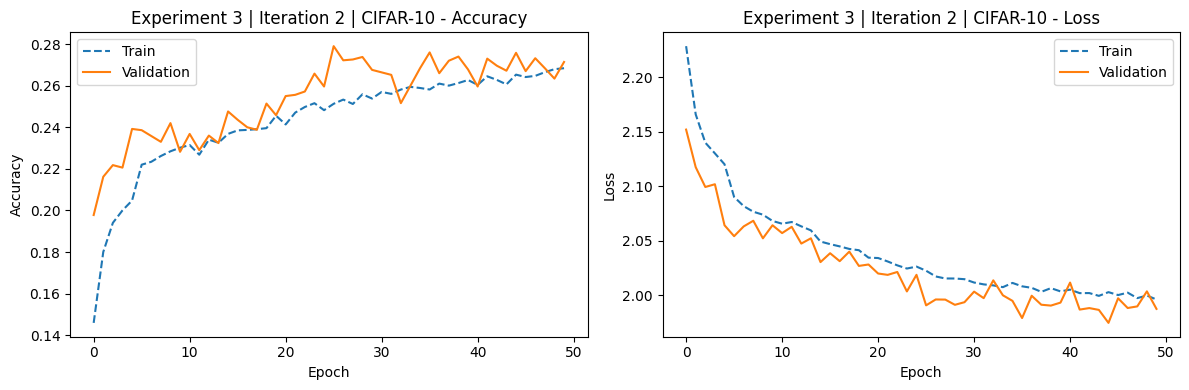

  Train loss      : 1.9961
  Validation loss : 1.9874
  Train accuracy  : 0.2684
  Validation acc  : 0.2714
  Generalization gap (val - train loss): -0.0086


In [56]:
# Training and evaluating the model

for i in range(3):
    run_experiment(
        f"Experiment 3 | Iteration {i} | CIFAR-10",
        cifar_x_train_gray_flat_df, 
        cifar_y_train_cat_df, 
        cifar_x_test_gray_flat_df, 
        cifar_y_test_cat_df,
        dropout_rate=dropout_rate
    )

# Experimento 4 - Com dropout e com early stop

Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1742 - loss: 2.1914 - val_accuracy: 0.2490 - val_loss: 2.0900
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2130 - loss: 2.1147 - val_accuracy: 0.2762 - val_loss: 2.0509
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2309 - loss: 2.0849 - val_accuracy: 0.2750 - val_loss: 2.0336
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2365 - loss: 2.0776 - val_accuracy: 0.2708 - val_loss: 2.0362
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2418 - loss: 2.0709 - val_accuracy: 0.2742 - val_loss: 2.0365
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2449 - loss: 2.0667 - val_accuracy: 0.2812 - val_loss: 2.0151
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2483 - loss: 2.0554 - val_accuracy: 0.2754 - val_loss: 2.0216
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2492 - loss: 2.0504 - val_accuracy: 0.2854 - val_

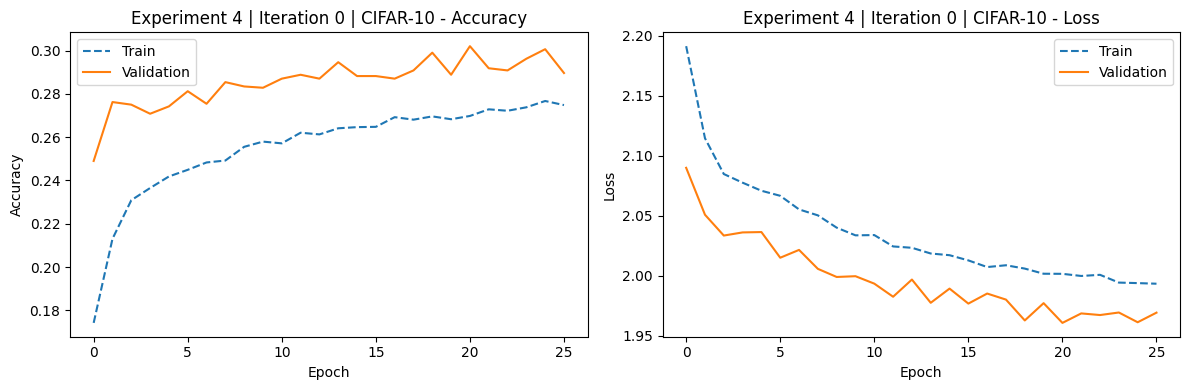

  Train loss      : 1.9935
  Validation loss : 1.9693
  Train accuracy  : 0.2748
  Validation acc  : 0.2896
  Generalization gap (val - train loss): -0.0241
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1852 - loss: 2.1769 - val_accuracy: 0.2496 - val_loss: 2.0852
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2368 - loss: 2.0819 - val_accuracy: 0.2812 - val_loss: 2.0172
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2500 - loss: 2.0468 - val_accuracy: 0.2858 - val_loss: 1.9885
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2522 - loss: 2.0395 - val_accuracy: 0.2866 - val_loss: 1.9877
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2593 - loss: 2.0179 - val_accuracy: 0.2934 - val_loss: 1.9639
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2655 - loss: 2.0075 - val_accuracy: 0.2858 - val_loss: 1.9701
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2692 - loss: 1.9971 - val_accuracy: 0.2858 - val_loss: 1.9614
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2709 - loss: 1.9894 - val_accuracy: 0.2944 - val_

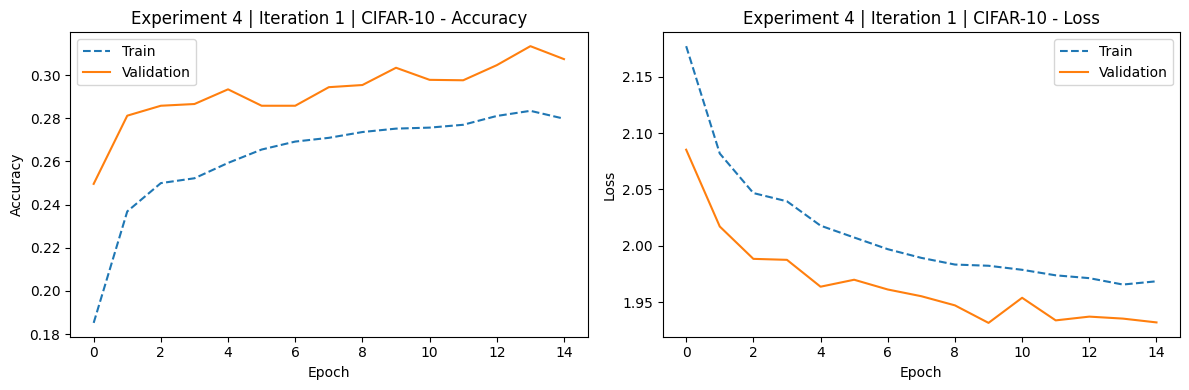

  Train loss      : 1.9687
  Validation loss : 1.9323
  Train accuracy  : 0.2798
  Validation acc  : 0.3074
  Generalization gap (val - train loss): -0.0364
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1718 - loss: 2.1941 - val_accuracy: 0.2418 - val_loss: 2.0810
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2184 - loss: 2.1044 - val_accuracy: 0.2770 - val_loss: 2.0352
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2331 - loss: 2.0772 - val_accuracy: 0.2836 - val_loss: 2.0178
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2379 - loss: 2.0641 - val_accuracy: 0.2828 - val_loss: 2.0068
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2499 - loss: 2.0448 - val_accuracy: 0.2826 - val_loss: 2.0067
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2530 - loss: 2.0332 - val_accuracy: 0.2840 - val_loss: 1.9929
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2565 - loss: 2.0276 - val_accuracy: 0.2920 - val_loss: 1.9829
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2627 - loss: 2.0183 - val_accuracy: 0.2888 - val_

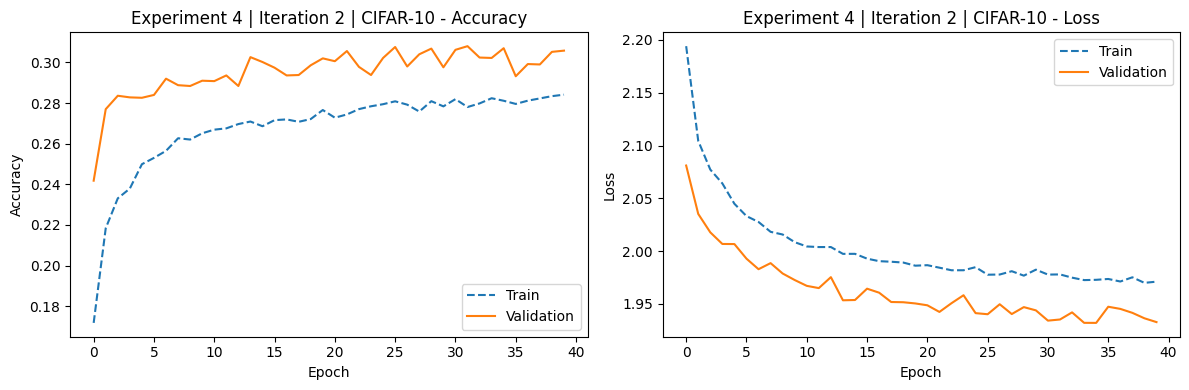

  Train loss      : 1.9711
  Validation loss : 1.9328
  Train accuracy  : 0.2841
  Validation acc  : 0.3058
  Generalization gap (val - train loss): -0.0383


In [57]:
# Training and evaluating the model

for i in range(3):
    run_experiment(
        f"Experiment 4 | Iteration {i} | CIFAR-10",
        cifar_x_train_gray_flat_df, 
        cifar_y_train_cat_df, 
        cifar_x_test_gray_flat_df, 
        cifar_y_test_cat_df,
        dropout_rate=dropout_rate,
        early_stopping=True,
        patience=early_stopping_patience
    )